# Automated Meal Plan Generation Using Optimization Techniques
---
## Project Overview

This notebook presents our **Genetic Algorithm (GA)** for generating optimal daily meal plans that satisfy macronutrient guidelines, caloric constraints, variety constraints and preferences. The system is designed around the **Saudi meal plan guidelines and the Bahrain food dataset**, incorporating calorie targets ranging from **1,200 to 2,200 kcal/day**.

### Approach

A **Genetic Algorithm** is used as the primary optimizer, with three comparative baselines evaluated under identical time budgets:

| Algorithm | Abbreviation |
|---|---|
| Genetic Algorithm | GA |
| Random Search | RS |
| Local Search (Hill Climbing) | LS |
| Simulated Annealing | SA |



## 1. Import Libraries

All required libraries are imported here. The project uses:

- **`deap`** — the Distributed Evolutionary Algorithms in Python framework, which provides the GA infrastructure (individuals, toolbox, operators, Hall of Fame, and statistics).
- **`numpy` / `scipy`** — numerical computation and statistical testing.
- **`matplotlib`** — visualization of results (box plots, histograms, fitness landscapes).
- **Standard library** — `random`, `csv`, `time`, `math`, `copy`, and `dataclasses` for supporting logic.


In [1]:
# Standard library imports
from dataclasses import dataclass
import random
import csv
import time
import math
import copy

# Numerical and scientific computing
import numpy as np
from scipy.stats import wilcoxon

# Visualization
import matplotlib.pyplot as plt

# DEAP — Evolutionary Algorithms Library
from deap import base, creator, tools, algorithms
from deap.tools import cxOnePoint, cxTwoPoints

# Reproducibility
random.seed(42)



## 2. Data Loading and Preprocessing

### 2.1 Chromosome and Gene Representation

Before loading data, we define the atomic unit of our solution: the **Gene**.

Each **Gene** represents one food item within a specific meal and food group. It stores:
- `food_item_name` — the selected food item from the dataset.
- `serving` — the number of servings assigned, determined by Saudi dietary guidelines.

A **Chromosome** (one complete day meal plan) consists of **30 genes**: 5 meals × 6 food groups.


In [2]:
@dataclass
class Gene:
    food_item_name: str
    serving: int

### 2.2 Meal and Food Group Structure

The daily meal plan is structured across five meals, each containing one item from each of the six food groups.


In [3]:
# The meals we have in 1 one day
Meals = ["Breakfast", "Snack 1", "Lunch", "Snack 2", "Dinner"]
# The food groups we have in 1 meal
Food_Groups = ["Vegetables", "Fruits", "Grains", "Protein", "Dairy", "Fats and Oils"]

### 2.3 Loading the Food Dataset

The dataset (`Processed_Bahrain_Food_Dataset.csv`) contains nutritional information for each food item, grouped by category. Each row stores:

- **Macronutrients**: Protein (g), Fats (g), Carbohydrates (g), Calories (kcal)
- **User Preference**: A numerical rating for the food item
- **Meal Flags**: Binary indicators specifying which meals this item is suitable for (e.g., Breakfast=1, Lunch=1)

The loader returns two dictionaries:
- `FOOD_DATA`: `{group → {food → nutritional stats}}`
- `MEAL_FLAGS`: `{food → {meal → 0 or 1}}`

Missing or non-numeric values are safely defaulted to `0` to prevent parsing errors.


In [4]:
def load_food_data(csv_path):
    """
    This function loads and parses the food dataset CSV into structured dictionaries.

    It returns:
        food_data  : dict mapping food group → food item → nutritional stats
        meal_flags : dict mapping food item → meal → suitability flag (0 or 1)
    """
    food_data = {}
    meal_flags = {}

    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            group = row['Category']
            food = row['Food Item']

            if group not in food_data:
                food_data[group] = {}

            # Safely convert numeric columns, use 0 if empty
            def safe_float(x):
                try:
                    return float(x)
                except (ValueError, TypeError):
                    return 0.0

            food_data[group][food] = {
                'p': safe_float(row['Protein (g)']),
                'f': safe_float(row['Fats (g)']),
                'c': safe_float(row['Carbohydrates (g)']),
                'cal': safe_float(row['Calories (kcal)']),
                'pref': safe_float(row['User Preference'])
            }

            # Safely convert meal flags (0 if empty)
            def safe_int(x):
                try:
                    return int(x)
                except (ValueError, TypeError):
                    return 0

            meal_flags[food] = {
                'Breakfast': safe_int(row['Breakfast']),
                'Snack 1': safe_int(row['Snack 1']),
                'Lunch': safe_int(row['Lunch']),
                'Snack 2': safe_int(row['Snack 2']),
                'Dinner': safe_int(row['Dinner'])
            }

    return food_data, meal_flags

# Load dataset into global variables
FOOD_DATA, MEAL_FLAGS = load_food_data("Processed_Bahrain_Food_Dataset.csv")

### 2.4 Saudi Dietary Serving Guidelines

The `SERVING_GUIDELINES_BY_KCAL` dictionary encodes the **official Saudi dietary serving recommendations** for 10 calorie levels (1,200 – 2,200 kcal/day).

For each calorie target, it specifies the exact number of servings required per food group per meal. These guidelines act as **hard structural constraints** — every chromosome is initialized to match them exactly.


In [5]:
SERVING_GUIDELINES_BY_KCAL = {
    1200: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 0},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1300: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1400: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1500: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1600: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1700: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1800: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    1900: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    2000: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    2200: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    }
}



## 3. Genetic Algorithm Implementation

This section implements the complete Genetic Algorithm using the **DEAP framework** with some changes to fit our methodology. Each component is described and implemented independently.



### 3.1 DEAP Configuration

DEAP is configured with a **maximization** fitness objective (`weights=(1.0,)`). Each individual is a list of `Gene` objects managed by a `creator.Individual` class. The `toolbox` serves as a registry for all genetic operators.


In [6]:
# Create DEAP fitness and individual types
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

### 3.2 Population Initialization

Each individual (chromosome) is created by the `create_individual` function. It constructs **30 genes** — one per (meal, food group) pair — by:

1. Looking up the required serving count from `SERVING_GUIDELINES_BY_KCAL` for the current `TARGET_KCAL`.
2. Filtering foods that are allowed for that meal using `MEAL_FLAGS`.
3. Randomly selecting one food item from the eligible candidates.

Serving counts are fixed to the guidelines; only the **food item selection** is randomized. This ensures every individual starts as a structurally valid meal plan.


In [7]:
def create_individual():

    """
    Generates a single chromosome: 30 genes covering 5 meals × 6 food groups.
    Serving sizes follow the Saudi dietary guidelines for TARGET_KCAL.
    Food items are randomly sampled from meal-appropriate candidates.
    """
    genes = []
    for meal in Meals:
        for group in Food_Groups:
            # Get the fixed serving count for this meal/group
            serving_count = SERVING_GUIDELINES_BY_KCAL[TARGET_KCAL][meal][group]

            # Filter foods allowed for this meal
            allowed_foods = [
                food for food in FOOD_DATA[group].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if not allowed_foods:
                allowed_foods = list(FOOD_DATA[group].keys()) # fallback if no meal-specific foods

            # Randomly select food from allowed foods
            food_name = random.choice(allowed_foods)

            # Create gene with guideline serving count
            genes.append(Gene(food_item_name=food_name, serving=serving_count))

    return creator.Individual(genes)


toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

### 3.3 Fitness Function

The fitness function `evaluate_meal_plan` evaluates a chromosome against four objectives, combined into a single weighted score:

| Objective | Symbol | Description                                                     |
|---|---|-----------------------------------------------------------------|
| Macronutrient balance | `j_macro` | Squared error between actual and AMDR target ratios (55/20/25%) |
| Calorie accuracy | `j_cal` | Squared relative error between total calories and `TARGET_KCAL` |
| Meal variety | `j_var` | Penalty for repeated food items across the plan                 |
| User preference | `j_pref` | Average user preference rating (lower = better)                 |

The final **score** is a weighted sum of these penalties. Since DEAP maximizes fitness, the score is transformed via `1 / (1 + score)`, mapping lower penalties to higher fitness values (range: 0–1).

Intermediate penalty values (`j_var`, `j_macro`, `j_cal`, `j_pref`) are stored directly on the individual for later inspection.


In [8]:
def evaluate_meal_plan(individual):
    """
    Evaluates a chromosome's fitness based on macro balance, calorie accuracy,
    meal variety, and user food preferences.

    Returns:
        A single-element tuple containing the fitness value (higher = better).
    """
    total_p = 0.0  # Protein grams
    total_f = 0.0  # Fat grams
    total_c = 0.0  # Carbohydrates grams
    total_cal = 0.0  # Total Calories
    total_pref = 0.0  # Total user preference

    # Sum up all grams and calories based on food item and serving count
    for gene in individual:
        group_name = None
        # Find which group this food belongs to
        for group, foods in FOOD_DATA.items():
            if gene.food_item_name in foods:
                group_name = group
                break

        if group_name:
            stats = FOOD_DATA[group_name][gene.food_item_name]
            total_p += stats['p'] * gene.serving
            total_f += stats['f'] * gene.serving
            total_c += stats['c'] * gene.serving
            total_cal += stats['cal'] * gene.serving
            if gene.serving > 0:
                total_pref += stats['pref']

    # Calculate actual macro percentages (p_c, p_p, p_f)
    g_total = total_p + total_f + total_c
    if g_total == 0: return 0,  # Avoid division by zero

    p_p = total_p / g_total
    p_f = total_f / g_total
    p_c = total_c / g_total

    # Target Ratios (The AMDR values)
    r_p, r_f, r_c = 0.20, 0.25, 0.55

    # Objective function: J_macro (Squared Error)
    j_macro = (p_c - r_c) ** 2 + (p_p - r_p) ** 2 + (p_f - r_f) ** 2

    # Total calorie constraint (J_cal)
    r = (total_cal - TARGET_KCAL) / TARGET_KCAL
    j_cal = min(1, r ** 2)

    # Variety constraint (J_var)
    N = sum(1 for gene in individual if
            gene.serving > 0)  # total number of food items in the chromosome
    # count food appearance
    food_appearance = {}
    for gene in individual:
        if gene.serving > 0:
            food_appearance[gene.food_item_name] = food_appearance.get(gene.food_item_name, 0) + 1
    # Calculate the penalty for variety
    j_var = 0
    for food_name, count in food_appearance.items():
        # we penalize if the food item appears more than once
        if count > 1:
            j_var += max(0, count - 1) ** 2
    # Normalize the penalty
    j_var = j_var / ((N - 1) ** 2)

    # User preference constraint (J_pref)
    j_pref = total_pref / N

    # Calculate the score
    w_macro, w_cal, w_var, w_pref = WEIGHTS
    score = w_macro * j_macro + w_var * j_var + w_cal * j_cal + w_pref * j_pref

    # store the penalties to print later
    individual.j_var = j_var
    individual.j_macro = j_macro
    individual.j_cal = j_cal
    individual.j_pref = j_pref

    # We want to minimize score, so we return a fitness that increases as score decreases
    return 1 / (1 + score),

### 3.4 Crossover Operators

Two meal-aware crossover operators are defined. Both operate at **meal boundaries** (i.e., cuts occur between complete meals, not mid-meal), preserving the structural integrity of each meal.

**One-Point Meal Crossover** (`one_cx_meal_plan`): selects a single meal cut point and swaps all subsequent meals between two parents.

**Two-Point Meal Crossover** (`two_cx_meal_plan`): selects two meal cut points and swaps the segment between them.

> **Note:** `cxOnePoint` from DEAP is registered as the active crossover operator; the custom meal-aware versions are defined for reference and experimentation.


In [9]:
def one_cx_meal_plan(parent1, parent2):
    """
    One-point crossover at a randomly chosen meal boundary.
    Swaps all genes from the cut point onward between the two parents.
    """
    GROUPS = 6
    MEALS = 5

    m1 = random.randrange(1, MEALS)
    cut = m1 * GROUPS
    parent1[cut:], parent2[cut:] = parent2[cut:], parent1[cut:]
    return parent1, parent2


def two_cx_meal_plan(parent1, parent2):
    """
    Two-point crossover at two randomly chosen meal boundaries.
    Swaps the segment between the two cut points between the two parents.
    """
    GROUPS = 6
    MEALS = 5

    # Choose 2 meal cut points
    m1, m2 = sorted(random.sample(range(1, MEALS), 2))
    cut1, cut2 = m1 * GROUPS, m2 * GROUPS

    # Swap full meals
    parent1[cut1:cut2], parent2[cut1:cut2] = parent2[cut1:cut2], parent1[cut1:cut2]

    return parent1, parent2

### 3.5 Mutation Operator

The `mutate_meal_plan` function implements a **targeted gene mutation**: for up to **2 genes** per call, a new food item is randomly selected from the allowed foods for that gene's (meal, food group) combination.

Key design decisions:
- **Serving sizes are never mutated** — only the food item name changes, preserving the guideline-based structure.
- **Meal compatibility is enforced** — only foods flagged for that meal in `MEAL_FLAGS` are considered.
- Genes with zero servings are skipped (they contribute nothing to the plan).


In [10]:
def mutate_meal_plan(individual):
    """
    Mutates up to 2 genes by replacing their food item with a randomly
    selected alternative from the same food group and meal.
    Serving counts remain unchanged.
    """
    mutations_done = 0
    all_indices = list(range(len(individual)))  # List of all possible indices in the chromosome
    random.shuffle(all_indices)  # Shuffle to pick randomly without repeating the same one

    for i in all_indices:
        if mutations_done >= 2:
            break  # Stop once we have mutated 2 genes

        # Check if the serving size is not zero
        if individual[i].serving > 0:
            # Find which group it belongs to (Vegetables, Grains, ...)
            group_name = Food_Groups[i % 6]
            # What meal it belongs to (Breakfast, Snack 1,...)
            meal = Meals[i // 6]

            # Check compatibility
            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                # Pick a new food name from food group dictionary, but the serving remains the same
                individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1
    return individual,



### 3.6 Selection and Operator Registration

**Tournament selection** (`selTournament` with `tournsize=3`) is used: three individuals are randomly drawn from the population and the fittest survives. This provides selection pressure while maintaining diversity.

All operators are registered in the DEAP `toolbox`.


In [11]:
toolbox.register("evaluate", evaluate_meal_plan)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", cxOnePoint)  # one-point crossover ( DEAP built in
toolbox.register("mutate", mutate_meal_plan)

### 3.7 Meal Plan Display Utility

The `print_meal_plan` function prints a structured nutritional summary for any chromosome, showing actual vs. target values for each objective component.


In [12]:
def print_meal_plan(individual):
    """Prints a formatted nutritional summary for a chromosome."""
    total_p = total_f = total_c = total_cal = 0.0

    for i, gene in enumerate(individual):
        meal  = Meals[i // 6]
        group = Food_Groups[i % 6]
        stats = FOOD_DATA[group][gene.food_item_name]

        total_p   += stats['p']   * gene.serving
        total_f   += stats['f']   * gene.serving
        total_c   += stats['c']   * gene.serving
        total_cal += stats['cal'] * gene.serving

    g_total          = total_p + total_f + total_c
    p_p              = (total_p / g_total) * 100
    p_f              = (total_f / g_total) * 100
    p_c              = (total_c / g_total) * 100
    variety          = (1 - individual.j_var)  * 100
    calories         = (total_cal / TARGET_KCAL) * 100
    preference_score = (1 - individual.j_pref) * 100

    print("\n" + "=" * 40)
    print("       DAILY NUTRITION SUMMARY")
    print("=" * 40)
    print(f"Total Energy:   {total_cal:.1f} kcal")
    print(f"Total Weight:   {g_total:.1f} g (Macro Grams)")
    print("-" * 40)
    print(f"Nutrient        | Actual % | Target %")
    print(f"Carbs (c)       | {p_c:>7.1f}% | 55.0%")
    print(f"Protein (p)     | {p_p:>7.1f}% | 20.0%")
    print(f"Fats (f)        | {p_f:>7.1f}% | 25.0%")
    print(f"Meal variety    | {variety:>7.1f}% | 100%")
    print(f"Meal calorie    | {calories:>7.1f}% | 100%")
    print(f"User preference | {preference_score:>7.1f}% | 100%")
    print("=" * 40)


## 4. Running the Genetic Algorithm

### 4.1 GA Execution Function

The `run_simulation` function encapsulates a complete GA run using DEAP's `eaMuPlusLambda` strategy — a **(μ + λ)** evolutionary strategy where:

- **μ** (mu) = population size — individuals selected into the next generation.
- **λ** (lambda) = 100 — offspring produced each generation via crossover and mutation.

#### Early Stopping

To avoid unnecessary computation, **early stopping with patience** is applied: if the best fitness does not improve by at least `EPS = 1e-6` for `PATIENCE` consecutive generations, evolution halts. The maximum number of generations is capped at **300**.

#### Parameters

| Parameter | Value | Description |
|---|---|---|
| `pop_size` | 95 | Population size (μ) |
| `cxpb` | 0.55 | Crossover probability |
| `mutpb` | 0.17 | Mutation probability |
| `patience` | 50 | Early stopping patience |
| `MAX_GEN` | 300 | Maximum generations |
| `lambda_` | 100 | Offspring per generation |

The function returns the **best fitness value** achieved and the **generation at which evolution stopped**.


In [13]:
def run_simulation(target_kcal, pop_size, cxpb, mutpb, patience):
    """
    Executes one full GA run for a given calorie target.

    Args:
        target_kcal : Daily calorie target (e.g., 1600).
        pop_size    : Number of individuals in the population (μ).
        cxpb        : Crossover probability per pair.
        mutpb       : Mutation probability per individual.
        patience    : Generations without improvement before early stopping.

    Returns:
        best_fitness : Best fitness value found across all generations.
        stopping_gen : The generation at which the run terminated.
    """
    global TARGET_KCAL, WEIGHTS
    TARGET_KCAL = target_kcal  # tells create_individual which guideline to use

    pop = toolbox.population(n=pop_size)

    hof = tools.HallOfFame(1)  # Keeps the absolute best found across all generations

    mu = len(pop)  # Number of individuals to select for the next generation
    lambd = 100  # Number of children to produce in each generation
    MAX_GEN = 300  #max num no more
    PATIENCE = patience
    EPS = 1e-6  #small new update ignor
    best_so_far = None
    stagnant = 0
    # Statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)
    for gen in range(MAX_GEN):

        # run ONE generation
        algorithms.eaMuPlusLambda(
            pop, toolbox,
            mu=mu,
            lambda_=lambd,
            cxpb=cxpb,
            mutpb=mutpb,
            ngen=1,
            stats=stats,
            halloffame=hof,
            verbose=False
        )
        hof.update(pop)

        current_best = hof[0].fitness.values[0]

        if best_so_far is None or current_best > best_so_far + EPS:
            best_so_far = current_best
            stagnant = 0
        else:
            stagnant += 1

        if stagnant >= PATIENCE:
            #print(f"\nEarly stopping at generation {gen + 1} (no improvement for {PATIENCE} gens)")
            break
    #print(f"Final Gen {gen + 1} | best={current_best:.8f} | stagnant={stagnant}/{PATIENCE}")
    #print("-" * 50)

    return hof[0].fitness.values[0], gen + 1

## 5. Comparative Algorithms

To rigorously evaluate the GA's performance, three baseline algorithms are implemented and run under **identical time budgets** (matched to each GA run's wall-clock time). This ensures a fair comparison where all algorithms receive equal computational resources.



### 5.1 Random Search (RS)

Random Search serves as the **lower bound baseline**. It repeatedly generates random individuals and retains the best found — no learning or memory is used.


In [14]:
def run_random_search(time_budget):
    """
    Generates random meal plans until the time budget is exhausted.
    Returns the best individual found and its fitness.

    Args:
        time_budget : Time in seconds to run the search.

    Returns:
        best_individual : Best chromosome found.
        best_fitness    : Fitness of the best chromosome.
        trials          : Total number of random individuals evaluated.
        total_time      : Actual elapsed time.
    """
    start_time = time.time()

    best_individual = None
    best_fitness = -float("inf")
    trials = 0

    while (time.time() - start_time) < time_budget:
        ind = create_individual()
        fitness = evaluate_meal_plan(ind)[0]
        trials += 1

        if fitness > best_fitness:
            best_fitness = fitness
            best_individual = ind
    end_time = time.time()
    total_time = end_time - start_time

    return best_individual, best_fitness, trials, total_time

### 5.2 Local Search

Local Search is a **greedy iterative improvement** algorithm. Starting from a random solution in the initial population, it repeatedly applies the mutation operator to generate a neighbour and accepts it only if it improves fitness. It is susceptible to local optima but benefits from focused exploitation.


In [15]:
def run_local_search(toolbox, pop_size, time_budget):
    """
    Performs hill-climbing local search within the given time budget.
    Starts from a randomly chosen individual in an initial population.

    Args:
        toolbox     : DEAP toolbox with registered operators.
        pop_size    : Size of the initial population to draw from.
        time_budget : Time in seconds to run the search.

    Returns:
        best        : Best chromosome found.
        best_fitness: Fitness of the best chromosome.
        trials      : Total number of neighbours evaluated.
    """
    start_time = time.time()

    # Generate initial population
    pop = toolbox.population(n=pop_size)

    # Evaluate population
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    # Pick A random solution from initial population
    current = toolbox.clone(random.choice(pop))

    best = toolbox.clone(current)
    best_fitness = current.fitness.values[0]

    trials = 0

    # Local search loop
    while (time.time() - start_time) < time_budget:

        neighbor = toolbox.clone(current)
        neighbor, = mutate_meal_plan(neighbor)

        neighbor.fitness.values = toolbox.evaluate(neighbor)
        trials += 1

        if neighbor.fitness.values[0] > current.fitness.values[0]:
            best = toolbox.clone(neighbor)
            best_fitness = neighbor.fitness.values[0]
            current = neighbor


    return best, best_fitness, trials

### 5.3 Simulated Annealing (SA)

Simulated Annealing extends Local Search by probabilistically **accepting worse solutions** early in the search (high temperature), gradually becoming more selective as temperature decreases (cooling schedule). This allows escape from local optima while converging to good solutions.

The **acceptance criterion** for a worse move is:

$$P(\text{accept}) = e^{-\Delta / T}$$

where $\Delta$ is the cost increase and $T$ is the current temperature.

#### SA Helper Functions

- `fitness_to_cost` — converts a fitness value back to a minimization cost (`1/f - 1`).
- `get_neighbor` — generates a neighbouring solution using the same mutation logic as the GA.


In [16]:
def fitness_to_cost(fitness):
    """Converts a fitness value to an equivalent minimization cost."""
    return (1 / fitness) - 1


def get_neighbor(individual):
    """
    Generates a neighbouring individual by mutating up to 2 food item selections.
    Uses a deep copy to avoid modifying the original.
    """
    new_individual = copy.deepcopy(individual)

    mutations_done = 0
    all_indices = list(range(len(new_individual)))
    random.shuffle(all_indices)

    for i in all_indices:
        if mutations_done >= 2:
            break

        if new_individual[i].serving > 0:
            group_name = Food_Groups[i % 6]
            meal = Meals[i // 6]

            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys()
                if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                new_individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1

    return new_individual


def run_simulated_annealing(toolbox, pop_size,
                            cooling_rate=0.98,
                            iterations_per_temp=200,
                            time_limit=None):

    # Generate population
    current = toolbox.individual()
    current_fitness = evaluate_meal_plan(current)[0]
    current_cost = fitness_to_cost(current_fitness)


    best = copy.deepcopy(current)
    best_fitness = current_fitness

    T = 1.0
    min_temp=0.001
    total_iterations = 0
    start_time = time.time()


    while T > min_temp:
        if time_limit and (time.time() - start_time) >= time_limit:
            break
        for _ in range(iterations_per_temp):

            new = get_neighbor(current)
            new_fitness = evaluate_meal_plan(new)[0]
            new_cost = fitness_to_cost(new_fitness)

            delta = new_cost - current_cost

            if delta <= 0 or random.random() < math.exp(-delta / T):
                current = new
                current_fitness = new_fitness
                current_cost = new_cost

            if current_fitness > best_fitness:
                best = copy.deepcopy(current)
                best_fitness = current_fitness

            total_iterations += 1

        T *= cooling_rate

    return best, best_fitness, total_iterations



## 6. Experiment Execution

### 6.1 Experimental Setup

The experiment evaluates all four algorithms across:
- **10 calorie targets**: 1,200 – 2,200 kcal/day
- **2 weight configurations**: emphasising macro/calorie balance vs. equal weighting
- **10 independent runs** per (target, weight) combination

Each baseline algorithm (RS, LS, SA) is run for **exactly the same wall-clock time** as the corresponding GA run. This ensures a fair, time-controlled comparison.

#### Weight Configurations

| Config | w_macro | w_cal | w_var | w_pref | Description |
|---|---|---|---|---|---|
| Config 1 | 0.35 | 0.35 | 0.20 | 0.10 | Emphasis on macros and calories |
| Config 2 | 0.25 | 0.25 | 0.25 | 0.25 | Equal weighting across all objectives |

#### GA Parameters (tuned)

| Parameter | Value |
|---|---|
| Population size | 95 |
| Crossover probability | 0.55 |
| Mutation probability | 0.17 |
| Early stopping patience | 50 generations |

All results are stored in `all_results[weights][target]` for downstream statistical analysis.


In [17]:
target_cals = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
WEIGHTS = (0.35, 0.35, 0.20, 0.10)

# GA best parameters
pop_size = 95
cxpb = 0.55
mutpb = 0.17
patience = 50

weight_configs = [ # loop over different weights
    (0.35, 0.35, 0.20, 0.10),
    (0.25, 0.25, 0.25, 0.25),
]

all_results = {}

# Execute 10 runs for each weight config in target cal
for weights in weight_configs:
    WEIGHTS = weights
    all_results[weights] = {}

    print(f"\n===== Weights {weights} =====")


    for target in target_cals:
        ga_fitness_list = []
        rs_fitness_list = []
        ls_fitness_list = []
        sa_fitness_list = []
        runtime_list = []

        print(f"\n===== Target {target} =====")
        print(f"{'Run':<5} {'StopGen(GA)':<13} {'Trials(RS)':<13} {'Trials(LS)':<13} {'Iter(SA)':<12} {'GA Fit':<12} {'RS Fit':<12} {'LS Fit':<12} {'SA Fit':<12} {'Time(s)':<12}")

        for run in range(1, 11):
            start_time = time.time()

            ga_fitness, stopping_gen = run_simulation(
                target,
                pop_size=pop_size,
                cxpb=cxpb,
                mutpb=mutpb,
                patience=patience
            )

            end_time = time.time()
            runtime_ga = end_time - start_time

            ga_fitness_list.append(ga_fitness)
            runtime_list.append(runtime_ga)

            # RS execution
            rs_best, rs_fitness, rs_trials, rs_time = run_random_search(runtime_ga)
            rs_fitness_list.append(rs_fitness)

            # Local Search execution
            start_time_ls = time.time()
            ls_best, ls_fitness, ls_trials = run_local_search(toolbox, pop_size, runtime_ga)
            end_time_ls = time.time()
            runtime_ls = end_time_ls - start_time_ls
            ls_fitness_list.append(ls_fitness)

            # SA execution
            start_time_sa = time.time()
            sa_best, sa_fitness, sa_iters = run_simulated_annealing(
                toolbox, pop_size, time_limit=runtime_ga
            )
            end_sa = time.time()
            runtime_sa = end_sa - start_time_sa
            sa_fitness_list.append(sa_fitness)

            print(f"{run:<5} {stopping_gen:<13} {rs_trials:<13} {ls_trials:<13} {sa_iters:<12} "
                f"{ga_fitness:<12.6f} {rs_fitness:<12.6f} {ls_fitness:<12.6f} {sa_fitness:<12.6f} "
                f"{runtime_ga:<12.4f}")

        all_results[weights][target] = {
            'ga': ga_fitness_list,
            'rs': rs_fitness_list,
            'ls': ls_fitness_list,
            'sa': sa_fitness_list,
        }

        # Stats
        avg_ga_fitness = np.mean(ga_fitness_list)
        max_ga_fitness = np.max(ga_fitness_list)
        min_ga_fitness = np.min(ga_fitness_list)
        std_ga_fitness = np.std(ga_fitness_list)

        avg_rs_fitness = np.mean(rs_fitness_list)
        max_rs_fitness = np.max(rs_fitness_list)
        min_rs_fitness = np.min(rs_fitness_list)
        std_rs_fitness = np.std(rs_fitness_list)

        avg_ls_fitness = np.mean(ls_fitness_list)
        max_ls_fitness = np.max(ls_fitness_list)
        min_ls_fitness = np.min(ls_fitness_list)
        std_ls_fitness = np.std(ls_fitness_list)

        avg_sa_fitness = np.mean(sa_fitness_list)
        max_sa_fitness = np.max(sa_fitness_list)
        min_sa_fitness = np.min(sa_fitness_list)
        std_sa_fitness = np.std(sa_fitness_list)

        avg_runtime_ga = np.mean(runtime_list)

        print("-" * 50)
        print(f"{'GA Avg fitness:':<25} {avg_ga_fitness:<12.6f}")
        print(f"{'GA Maximum fitness:':<25} {max_ga_fitness:<12.6f}")
        print(f"{'GA Minimum fitness:':<25} {min_ga_fitness:<12.6f}")
        print(f"{'GA Fitness std:':<25} {std_ga_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'RS Avg fitness:':<25} {avg_rs_fitness:<12.6f}")
        print(f"{'RS Maximum fitness:':<25} {max_rs_fitness:<12.6f}")
        print(f"{'RS Minimum fitness:':<25} {min_rs_fitness:<12.6f}")
        print(f"{'RS Fitness std:':<25} {std_rs_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'LS Avg fitness:':<25} {avg_ls_fitness:<12.6f}")
        print(f"{'LS Maximum fitness:':<25} {max_ls_fitness:<12.6f}")
        print(f"{'LS Minimum fitness:':<25} {min_ls_fitness:<12.6f}")
        print(f"{'LS Fitness std:':<25} {std_ls_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'SA Avg fitness:':<25} {avg_sa_fitness:<12.6f}")
        print(f"{'SA Maximum fitness:':<25} {max_sa_fitness:<12.6f}")
        print(f"{'SA Minimum fitness:':<25} {min_sa_fitness:<12.6f}")
        print(f"{'SA Fitness std:':<25} {std_sa_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'Avg Runtime (GA):':<25} {avg_runtime_ga:<12.4f}")


===== Weights (0.35, 0.35, 0.2, 0.1) =====

===== Target 1200 =====
Run   StopGen(GA)   Trials(RS)    Trials(LS)    Iter(SA)     GA Fit       RS Fit       LS Fit       SA Fit       Time(s)     
1     80            13230         10046         10600        0.982064     0.956982     0.981658     0.956030     1.8907      
2     89            11955         10528         10200        0.981203     0.958877     0.984526     0.963269     1.7706      
3     196           29083         22982         22600        0.985535     0.963753     0.982406     0.961865     4.0157      
4     196           26558         23095         21400        0.981486     0.959470     0.979898     0.962662     4.1716      
5     150           21805         17973         19200        0.987516     0.969068     0.980230     0.959379     3.2350      
6     97            12889         10404         10400        0.985163     0.955759     0.983341     0.952527     2.0308      
7     254           36551         29896         3



## 7. Statistical Analysis

### 7.1 Wilcoxon Signed-Rank Test

The **Wilcoxon signed-rank test** is a non-parametric paired statistical test used to determine whether the median difference between two paired samples is significantly different from zero.

It is chosen over a paired t-test because:
- Fitness values may not follow a normal distribution.
- Sample sizes are small (n = 10 runs).
- It is robust to outliers.

**Null hypothesis (H₀):** There is no significant difference in median fitness between the two algorithms.
**Significance level:** α = 0.05 (p-value < 0.05 → reject H₀ → significant difference).

All pairwise comparisons are computed: GA vs RS, GA vs LS, GA vs SA, RS vs LS, RS vs SA, and LS vs SA.


In [18]:
print(f"{'Target':<10} {'Comparison':<20} {'Statistic':<15} {'p-value':<15} {'Significant?':<15}")
print("-" * 75)

for weights in weight_configs:
    print(f"\n========== Weights: {weights} ==========")

    for target in target_cals:
        ga = all_results[weights][target]['ga']
        rs = all_results[weights][target]['rs']
        ls = all_results[weights][target]['ls']
        sa = all_results[weights][target]['sa']

        comparisons = [
            ('GA vs RS', ga, rs),
            ('GA vs LS', ga, ls),
            ('GA vs SA', ga, sa),
            ('RS vs LS', rs, ls),
            ('RS vs SA', rs, sa),
            ('LS vs SA', ls, sa),
        ]

        print(f"\n===== Target {target} =====")
        for name, a, b in comparisons:
            try:
                stat, p = wilcoxon(a, b)
                sig = "Yes" if p < 0.05 else "No"
                print(f"{name:<20} {stat:<15.4f} {p:<15.4f} {sig:<15}")
            except ValueError as e:
                print(f"{name:<20} Skipped ({e})")

        print("-" * 75)

Target     Comparison           Statistic       p-value         Significant?   
---------------------------------------------------------------------------

========== Weights: (0.35, 0.35, 0.2, 0.1) ==========

===== Target 1200 =====
GA vs RS             0.0000          0.0020          Yes            
GA vs LS             9.0000          0.0645          No             
GA vs SA             0.0000          0.0020          Yes            
RS vs LS             0.0000          0.0020          Yes            
RS vs SA             23.0000         0.6953          No             
LS vs SA             0.0000          0.0020          Yes            
---------------------------------------------------------------------------

===== Target 1300 =====
GA vs RS             0.0000          0.0020          Yes            
GA vs LS             0.0000          0.0020          Yes            
GA vs SA             0.0000          0.0020          Yes            
RS vs LS             0.0000          0.002

### 7.2 Fitness Distribution Box Plots

Box plots are used to visualise the **distribution of fitness values** across 10 runs for each algorithm and calorie target. They show the median, interquartile range (IQR), and any outliers.

A separate figure is generated for each weight configuration, with one subplot per calorie target. Higher and tighter boxes indicate a more consistently performant algorithm.


C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' p

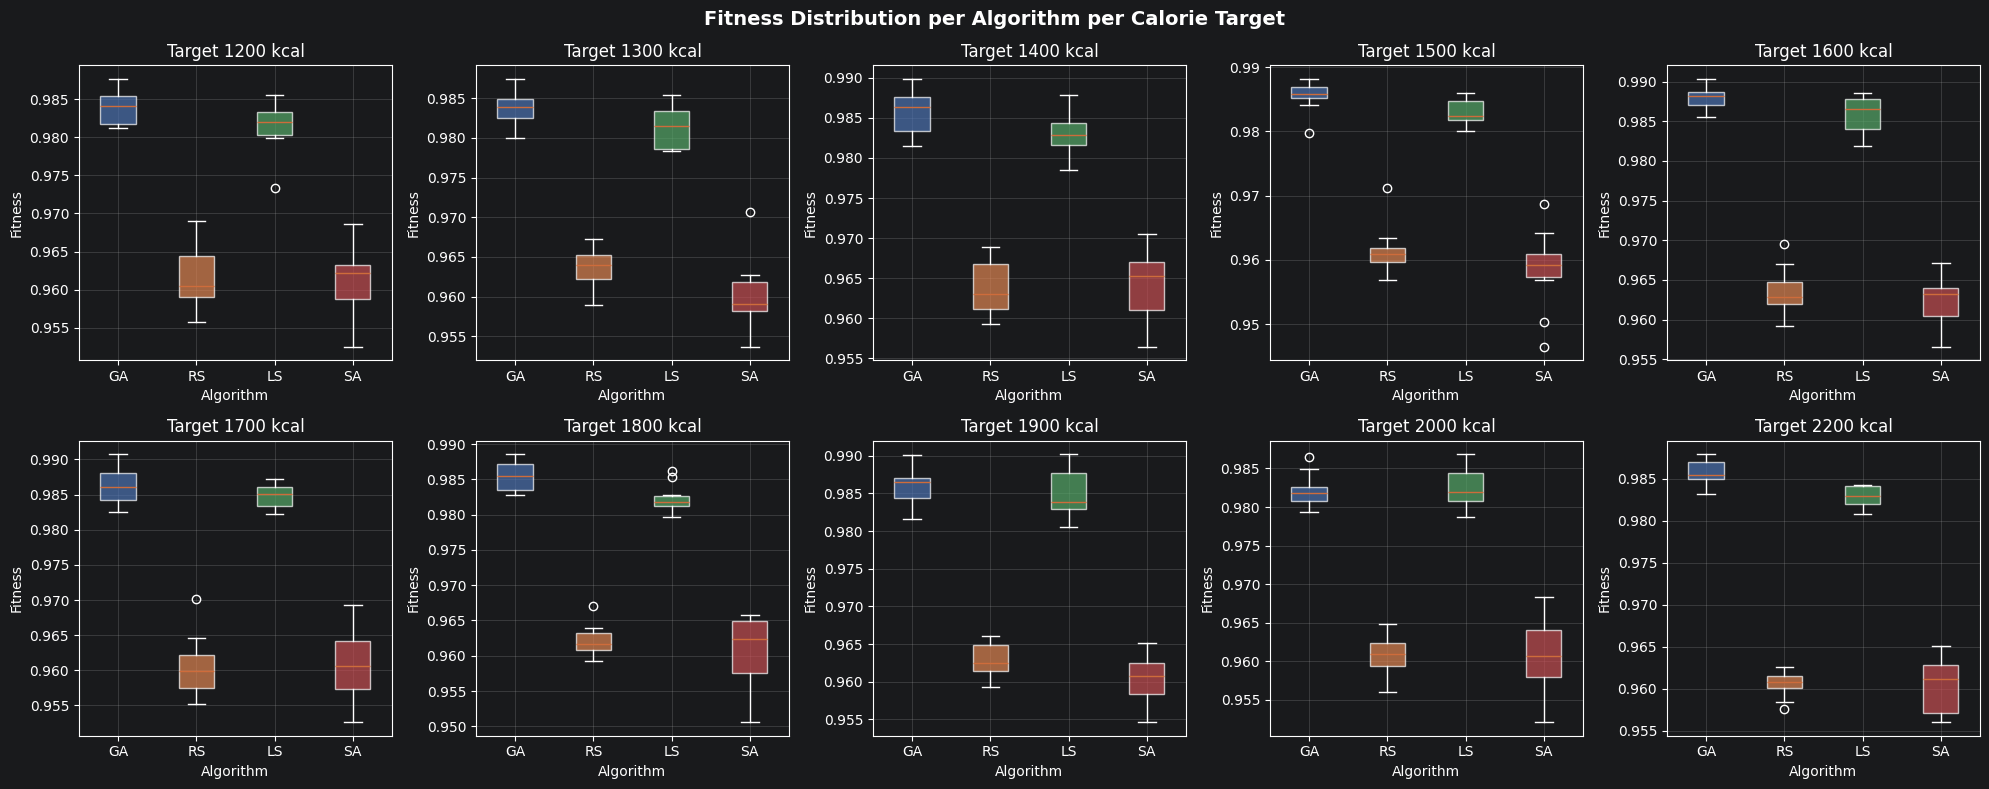

C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_3272\3596063934.py:14: MatplotlibDeprecationWarning: The 'labels' p

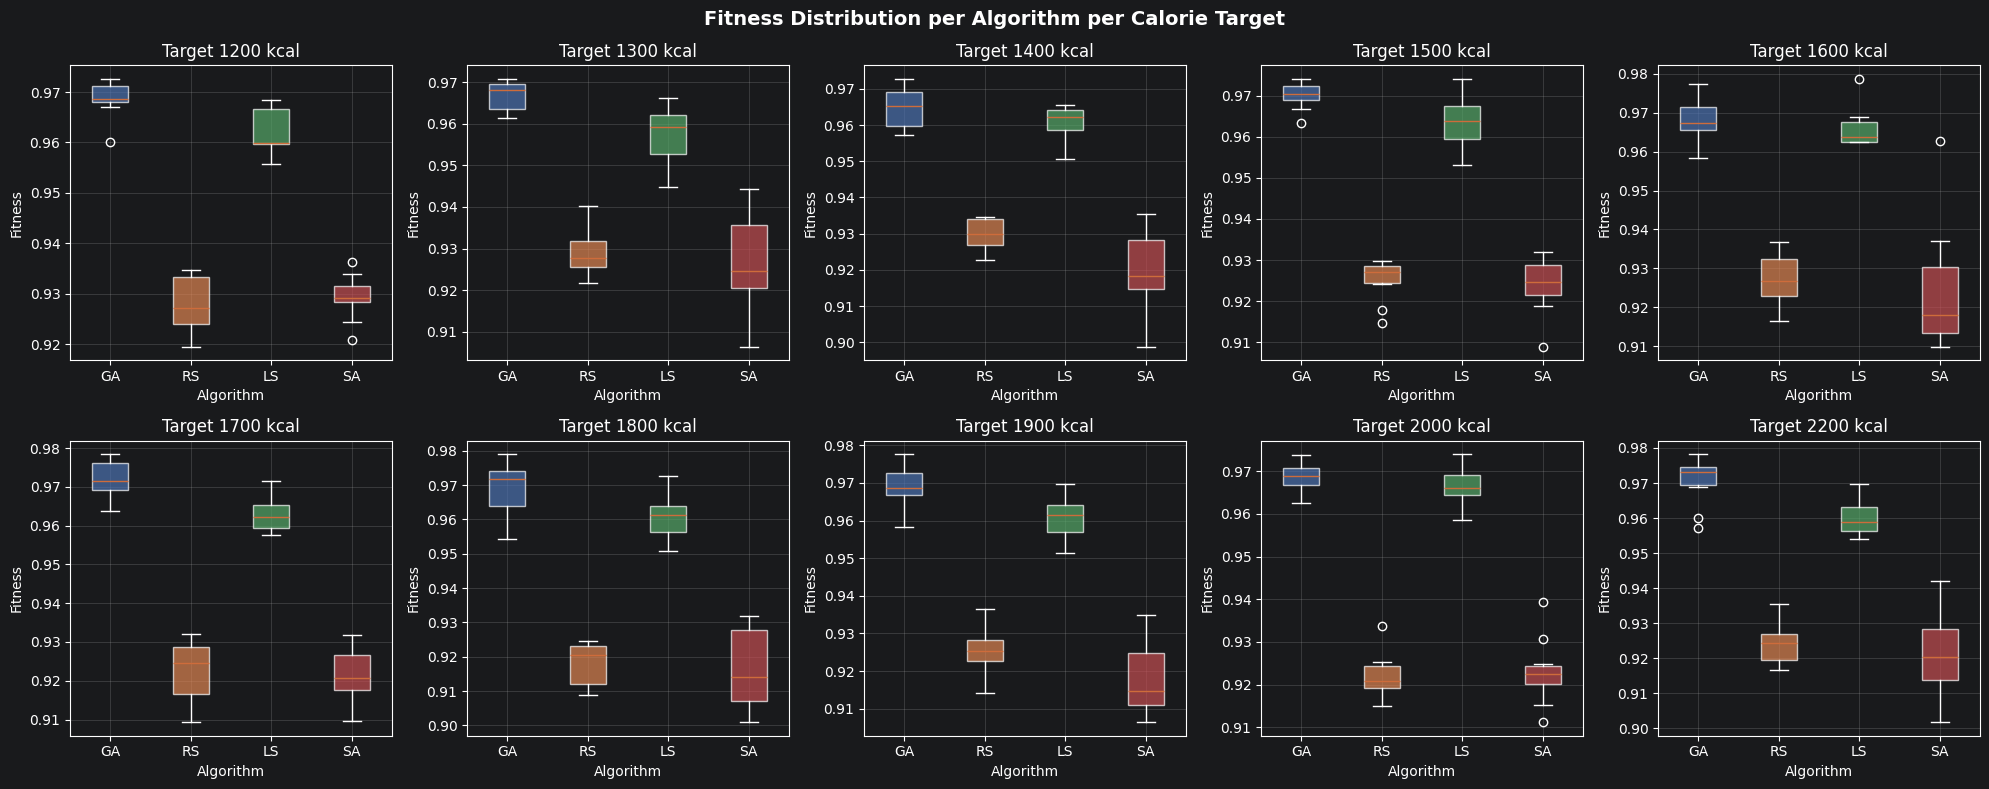

In [19]:
for weights in weight_configs:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, target in enumerate(target_cals):
        ga = all_results[weights][target] ['ga']
        rs = all_results[weights][target]['rs']
        ls = all_results[weights][target]['ls']
        sa = all_results[weights][target]['sa']

        data = [ga, rs, ls, sa]
        labels = ['GA', 'RS', 'LS', 'SA']

        bp = axes[i].boxplot(data, labels=labels, patch_artist=True)

        colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[i].set_title(f'Target {target} kcal')
        axes[i].set_xlabel('Algorithm')
        axes[i].set_ylabel('Fitness')
        axes[i].grid(True, alpha=0.3)

    plt.suptitle('Fitness Distribution per Algorithm per Calorie Target', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'boxplot_{weights}.png', dpi=300, bbox_inches='tight')
    plt.show()

### 7.3 Fitness Landscape Analysis

The **fitness landscape** characterizes the structure of the search space — how fitness varies as solutions change. Understanding the landscape informs why the GA may outperform or underperform relative to other algorithms.

Two complementary analyses are performed:

#### 7.3.1 Ruggedness — Random Walk Autocorrelation

A **random walk** is performed on the landscape: starting from a random individual, the mutation operator is applied repeatedly and fitness is recorded at each step. The **autocorrelation** at lag 1 measures how correlated adjacent fitness values are:

- **Autocorrelation ≈ 1**: smooth landscape (easy for gradient-based methods).
- **Autocorrelation ≈ 0**: rugged landscape (many ups and downs — harder to search).

#### 7.3.2 Local Optima Count

Multiple **independent hill-climbing runs** are launched from different random starting points. The fitness values at convergence are collected. A large spread of distinct local optima indicates a **multi-modal landscape**, which justifies the GA's population-based exploration strategy.


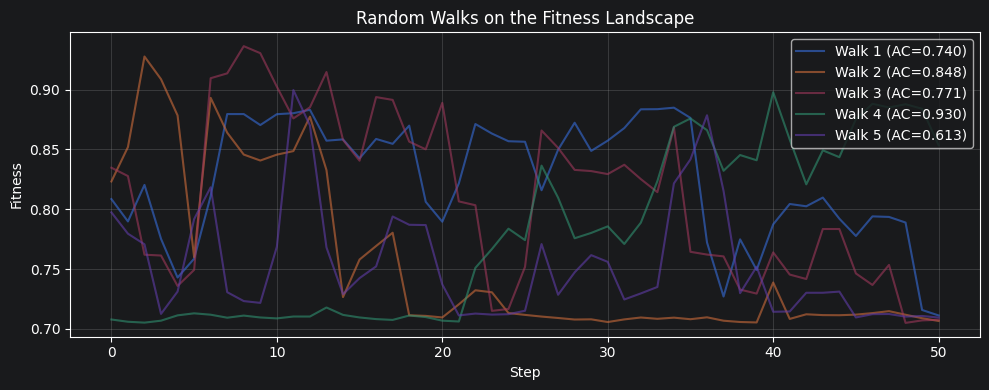

Mean Autocorrelation: 0.7802  (closer to 1 = smoother landscape)

Local Optima Analysis (50 random starts):
  Unique local optima found : 33
  Best                      : 0.988900
  Worst                     : 0.979700
  Std                       : 0.002317  (higher = more varied landscape)


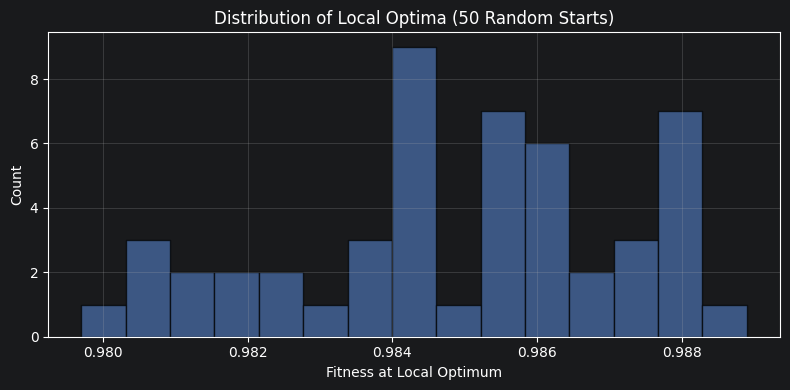

In [20]:
# Landscape analysis configuration
N_WALKS     = 5       # Number of random walks for ruggedness estimation
WALK_LENGTH = 50      # Steps per random walk
N_STARTS    = 50      # Starting points for local optima enumeration

# Fix target and weights for landscape analysis
TARGET_KCAL = 1600
WEIGHTS     = (0.35, 0.35, 0.20, 0.10)


#  7.3.1 Ruggedness: Random Walk Autocorrelation

def random_walk_autocorrelation(walk_length, lag=1):
    """
    Performs a random walk and computes autocorrelation at the given lag.
    Returns the fitness sequence and the autocorrelation coefficient.
    """
    ind         = create_individual()
    fitness_seq = [evaluate_meal_plan(ind)[0]]

    for _ in range(walk_length):
        ind, = mutate_meal_plan(ind)
        fitness_seq.append(evaluate_meal_plan(ind)[0])

    mean  = np.mean(fitness_seq)
    diffs = np.array(fitness_seq) - mean
    ac    = np.sum(diffs[:-lag] * diffs[lag:]) / np.sum(diffs ** 2)
    return fitness_seq, ac


all_ac = []
plt.figure(figsize=(10, 4))

for i in range(N_WALKS):
    seq, ac = random_walk_autocorrelation(WALK_LENGTH)
    all_ac.append(ac)
    plt.plot(seq, alpha=0.6, label=f'Walk {i+1} (AC={ac:.3f})')

plt.xlabel('Step')
plt.ylabel('Fitness')
plt.title('Random Walks on the Fitness Landscape')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Autocorrelation: {np.mean(all_ac):.4f}  (closer to 1 = smoother landscape)")


# 7.3.2 Local Optima Count

def find_local_optimum(toolbox, time_budget=2.0):
    """
    Runs hill climbing from a random start and returns the fitness at convergence.
    Rounds to 4 decimal places to group near-identical optima.
    """
    ind = create_individual()
    ind.fitness.values = evaluate_meal_plan(ind)
    start = time.time()

    while (time.time() - start) < time_budget:
        neighbor, = mutate_meal_plan(toolbox.clone(ind))
        neighbor.fitness.values = evaluate_meal_plan(neighbor)
        if neighbor.fitness.values[0] > ind.fitness.values[0]:
            ind = neighbor

    return round(ind.fitness.values[0], 4)


local_optima  = [find_local_optimum(toolbox) for _ in range(N_STARTS)]
unique_optima = set(local_optima)

print(f"\nLocal Optima Analysis ({N_STARTS} random starts):")
print(f"  Unique local optima found : {len(unique_optima)}")
print(f"  Best                      : {max(local_optima):.6f}")
print(f"  Worst                     : {min(local_optima):.6f}")
print(f"  Std                       : {np.std(local_optima):.6f}  (higher = more varied landscape)")

plt.figure(figsize=(8, 4))
plt.hist(local_optima, bins=15, color='#4C72B0', alpha=0.7, edgecolor='black')
plt.xlabel('Fitness at Local Optimum')
plt.ylabel('Count')
plt.title(f'Distribution of Local Optima ({N_STARTS} Random Starts)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 7.4 Fitness Distributions: Random Search vs. Genetic Algorithm

To further characterise the solution space, two fitness distributions are sampled and visualised:

1. **Random Search Distribution** (1,000 random individuals): represents the raw distribution of the search space — a baseline of what is achievable without any directed search.
2. **GA Distribution** (100 independent GA runs): shows what the GA consistently achieves, demonstrating its ability to shift the distribution toward higher-fitness regions.

A clear rightward shift in the GA distribution relative to the RS distribution confirms that the GA is effectively exploiting the search space.


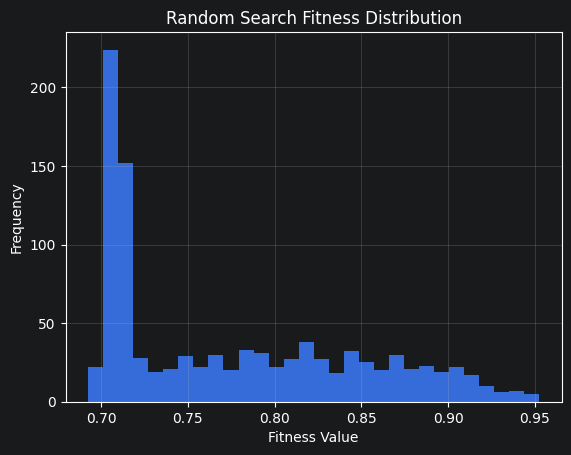

In [21]:
# Random Search Landscape Distribution

TARGET_KCAL = 1600
WEIGHTS = (0.35, 0.35, 0.20, 0.10)

random.seed(42)
np.random.seed(42)

fitness_values = []

for _ in range(1000):
    ind = create_individual()
    fitness = evaluate_meal_plan(ind)[0]
    fitness_values.append(fitness)

import matplotlib.pyplot as plt

plt.hist(fitness_values, bins=30)
plt.xlabel("Fitness Value")
plt.ylabel("Frequency")
plt.title("Random Search Fitness Distribution")
plt.grid(True, alpha=0.3)
plt.show()

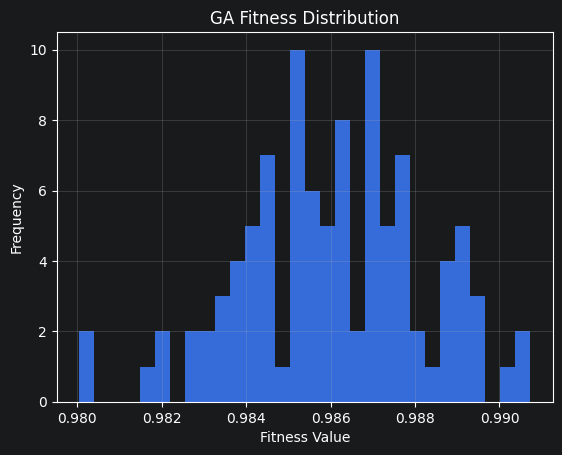

In [22]:
# 7.4.2 GA Fitness Distribution (100 Independent Runs)

ga_fitness_values = []

NUM_RUNS = 100

for _ in range(NUM_RUNS):

    ga_fitness, _ = run_simulation(
        target_kcal=1600,
        pop_size=95,
        cxpb=0.55,
        mutpb=0.17,
        patience=50
    )

    ga_fitness_values.append(ga_fitness)

plt.hist(ga_fitness_values, bins=30)

plt.xlabel("Fitness Value")
plt.ylabel("Frequency")
plt.title("GA Fitness Distribution")

plt.grid(True, alpha=0.3)

plt.show()